In [1]:
!pip install scikit-learn xgboost imbalanced-learn matplotlib seaborn pandas numpy


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r'D:\Major Project\DATASETS MAJOR PROJECT\creditcard.csv\creditcard.csv')

print("Shape:", df.shape)
print("Fraud cases:", df['Class'].sum())
print(df.head())

Shape: (284807, 31)
Fraud cases: 492
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010

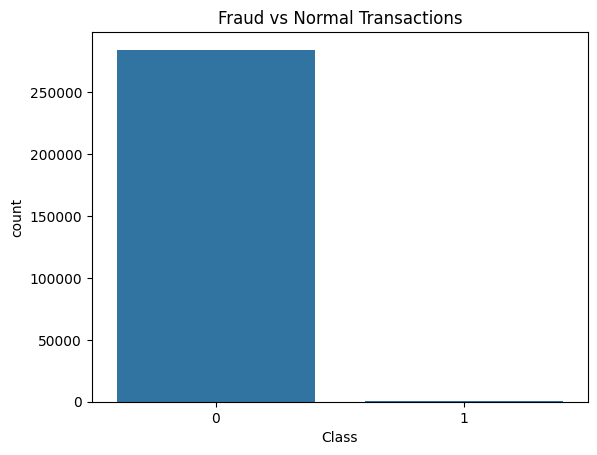

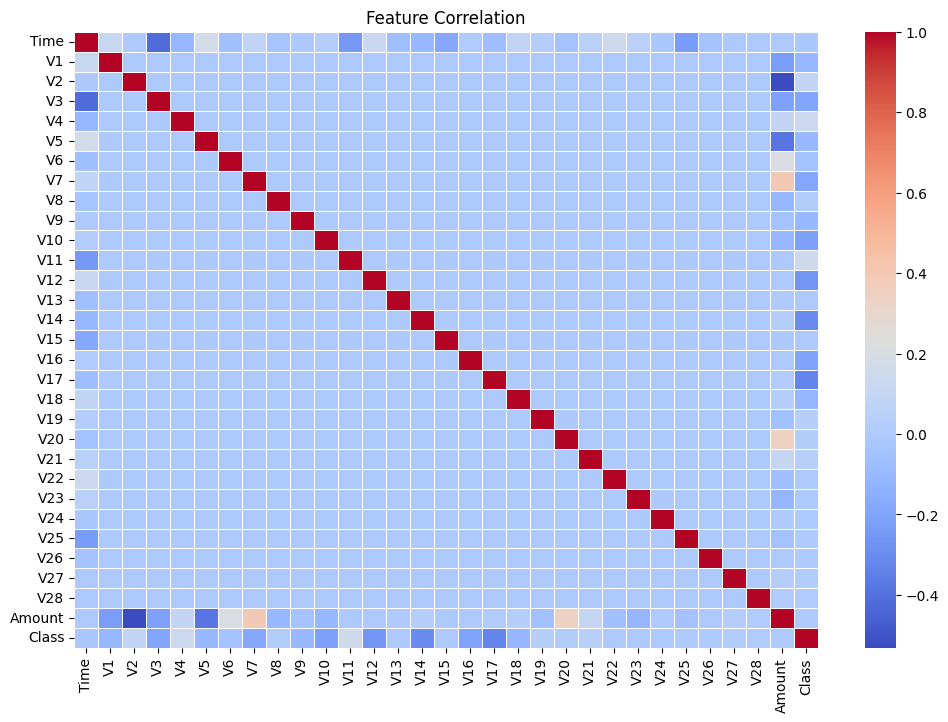

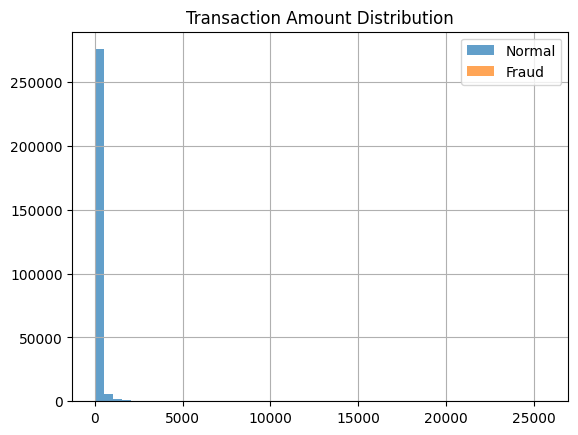

In [3]:
# Class distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation")
plt.show()

# Amount distribution
df[df['Class']==0]['Amount'].hist(bins=50, label='Normal', alpha=0.7)
df[df['Class']==1]['Amount'].hist(bins=50, label='Fraud', alpha=0.7)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time']   = scaler.fit_transform(X[['Time']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_sm.value_counts())

After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.973103297664029


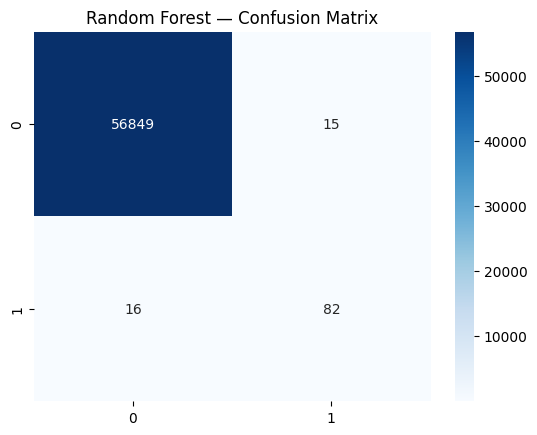

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9791588308086319


D:\python-3.12.10\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 64)               │          24,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,281 (145.63 KB)

 Trainable params: 37,281 (145.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9786 - loss: 0.0664 - val_accuracy: 0.9951 - val_loss: 0.0127
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9939 - loss: 0.0179 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9965 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9981 - loss: 0.0069 - val_accuracy: 0.9998 - val_loss: 0.0018
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9987 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 6.3310e-04
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9989 - loss:

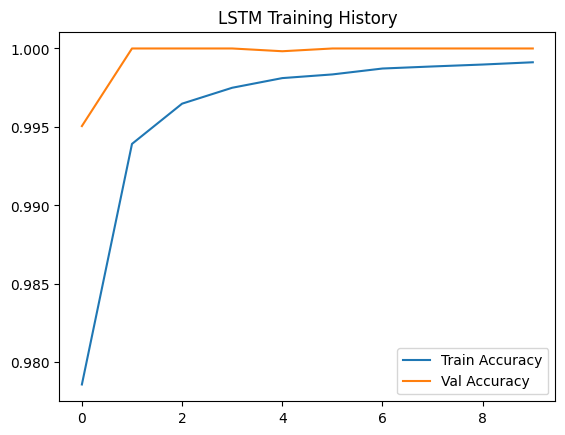

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape for LSTM — (samples, timesteps, features)
X_train_lstm = X_train_sm.values.reshape((X_train_sm.shape[0], 1, X_train_sm.shape[1]))
X_test_lstm  = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build LSTM model
model_lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_sm.shape[1]), return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

history = model_lstm.fit(
    X_train_lstm, y_train_sm,
    epochs=10, batch_size=256,
    validation_split=0.1, verbose=1
)

# Plot training
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("LSTM Training History")
plt.show()

               Accuracy  F1 Score   ROC AUC
Random Forest  0.999456  0.841026  0.973103
XGBoost        0.999245  0.801843  0.979159


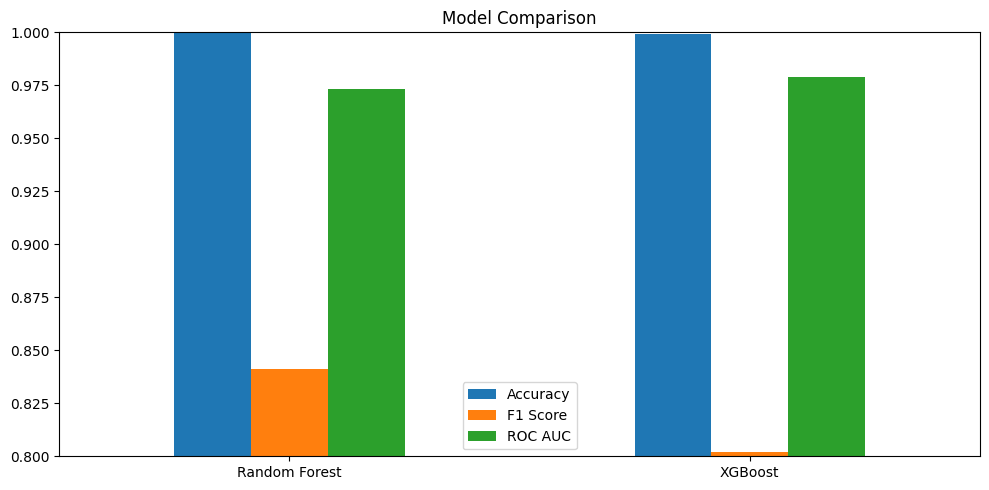

In [8]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

results = {
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'F1 Score': f1_score(y_test, y_pred_rf),
        'ROC AUC': roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'F1 Score': f1_score(y_test, y_pred_xgb),
        'ROC AUC': roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
    }
}

results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

In [9]:
import pickle

# Save models
pickle.dump(rf,  open(r'D:\Major Project\model\rf_model.pkl', 'wb'))
pickle.dump(xgb, open(r'D:\Major Project\model\xgb_model.pkl', 'wb'))
model_lstm.save(r'D:\Major Project\model\lstm_model.h5')

print("✅ All models saved!")

✅ All models saved!


In [10]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/38.1 MB 9.1 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/38.1 MB 8.2 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/38.1 MB 6.7 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/38.1 MB 5.4 MB/s eta 0:00:07
   ------ --------------------------------- 5.8/38.1 MB 5.1 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/38.1 MB 4.4 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/38.1 MB 3.9 MB/s eta 0:00:08
   ------- -------------------------------- 7.1/38.1 MB 3.7 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/38.1 MB 3.6 MB/s eta 0:00:09
   -------- ------------------------------- 7.

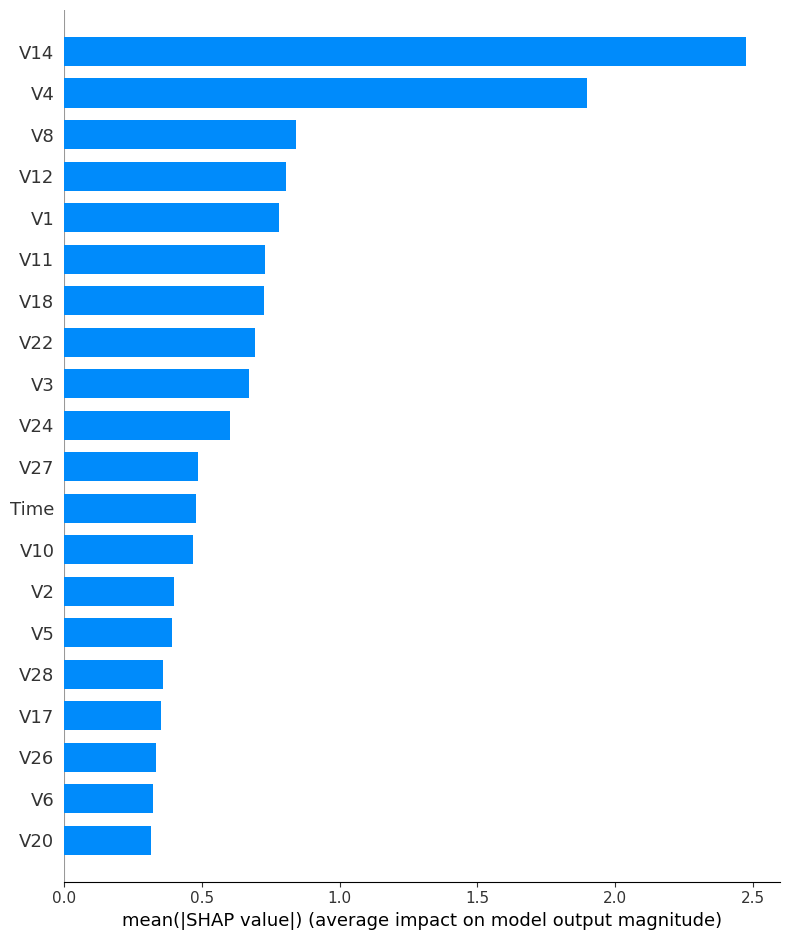

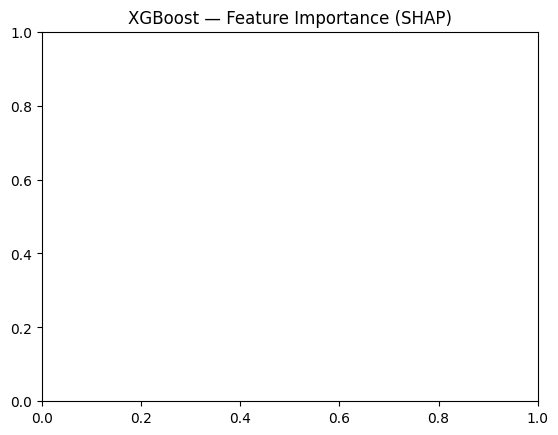

In [11]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(shap_values, X_test[:100], plot_type='bar')
plt.title("XGBoost — Feature Importance (SHAP)")
plt.show()

In [12]:
print("=" * 50)
print("   MULTIMODAL FINTECH RISK ASSESSMENT")
print("   Model Training Summary")
print("=" * 50)
print(results_df.to_string())
print("\n✅ Models saved at: D:/Major Project/model/")

   MULTIMODAL FINTECH RISK ASSESSMENT
   Model Training Summary
               Accuracy  F1 Score   ROC AUC
Random Forest  0.999456  0.841026  0.973103
XGBoost        0.999245  0.801843  0.979159

✅ Models saved at: D:/Major Project/model/
